# **Fake news detection**






In [ ]:
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sentence_transformers import SentenceTransformer

In [ ]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake["label"] = 0
true["label"] = 1

data = pd.concat([fake, true])
data = data.sample(frac=1).reset_index(drop=True)

data.head()

,title,text,subject,date,label
0,FOUR PREVIOUSLY DEPORTED ILLEGAL ALIENS Charge...,There are numerous crimes we report on every d...,politics,"Mar 19, 2016",0
1,UK lawmakers ask Facebook for any evidence of ...,LONDON (Reuters) - A British parliamentary com...,worldnews,"October 24, 2017",1
2,WATCH: President ‘No F*cks Left’ Obama Tears ...,"Fox News, Donald Trump, and the rest of the ha...",News,"June 2, 2016",0
3,Trump open to Social Security changes if elect...,WASHINGTON (Reuters) - Republican Donald Trump...,politicsNews,"May 11, 2016",1
4,WATCH: Mika Brzezinski UNLOADS Fury Against T...,The men of Morning Joe found Donald Trump s in...,News,"September 29, 2016",0


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

data["text"] = data["text"].apply(clean_text)

In [ ]:
X = data["text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf = tfidf.transform(X_test).toarray()

In [ ]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')

X_train_embed = embedder.encode(X_train.tolist(),
    batch_size=32,
    show_progress_bar=True)
X_test_embed = embedder.encode(X_test.tolist(),
    batch_size=32,
    show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1123 [00:00<?, ?it/s]

Batches:   0%|          | 0/281 [00:00<?, ?it/s]

In [ ]:
X_train_final = np.hstack((X_train_tfidf, X_train_embed))
X_test_final = np.hstack((X_test_tfidf, X_test_embed))

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_final, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
preds = model.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.9915367483296214
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4666
           1       0.99      0.99      0.99      4314

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



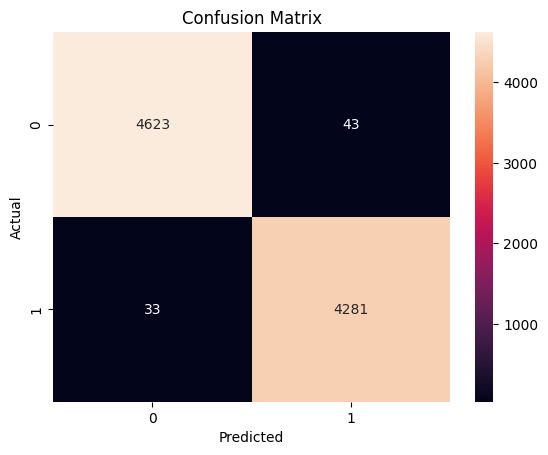

In [ ]:
cm = confusion_matrix(y_test, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
def get_top_words(text, tfidf, top_n=5):
    vec = tfidf.transform([text])
    feature_names = tfidf.get_feature_names_out()
    scores = vec.toarray()[0]

    top_indices = scores.argsort()[-top_n:][::-1]
    words = [feature_names[i] for i in top_indices]

    return words

sample_text = X_test.iloc[0]
print("Top Words:", get_top_words(sample_text, tfidf))

Top Words: ['biden', 'joe', 'the', 'girl', 'little']


In [ ]:
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))
pickle.dump(embedder, open("embedder.pkl", "wb"))